## 프로젝트 개요 및 환경 설정

### 라이브러리 설치 및 Import

In [96]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


### 데이터 로드

In [97]:
# 데이터 로드
df = pd.read_csv('../../data/DieCasting_Quality_Raw_Data.csv', header=1)  # ('Process', 'id') 멀티 헤더라서
df.columns = df.columns.str.strip()

print("="*60)
print("데이터 로드 완료!")
print("="*60)

데이터 로드 완료!


## 데이터 이해

### 데이터 구조 파악

In [98]:
print("\n" + "="*60)
print("DieCasting 데이터")
print("="*60)
print(f"\nDieCasting: {df.shape}")
print("\n[Data Info]")
df.info()


DieCasting 데이터

DieCasting: (7535, 57)

[Data Info]
<class 'pandas.DataFrame'>
RangeIndex: 7535 entries, 0 to 7534
Data columns (total 57 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    7535 non-null   int64  
 1   Product_Type          7535 non-null   int64  
 2   Shot                  7535 non-null   int64  
 3   Velocity_1            7535 non-null   float64
 4   Velocity_2            7535 non-null   float64
 5   Velocity_3            7535 non-null   float64
 6   High_Velocity         7535 non-null   float64
 7   Cylinder_Pressure     7535 non-null   int64  
 8   Rapid_Rise_Time       7535 non-null   float64
 9   Biscuit_Thickness     7535 non-null   int64  
 10  Clamping_Force        7535 non-null   int64  
 11  Cycle_Time            7535 non-null   float64
 12  Pressure_Rise_Time    7535 non-null   float64
 13  Casting_Pressure      7535 non-null   int64  
 14  Spray_Time            7535 non

### 컬럼별 의미 및 데이터 타입 확인

In [99]:
# =======================================================
# DieCasting 주요 컬럼 설명
# =======================================================
# [공정 변수]
# • id                            : 고유 식별자 (각 Shot에 부여된 고유 ID (연속적이지 않음))
# • Product_Type                  : 제품 유형 (생산 제품 종류 구분 (1: 4,207건 / 2: 3,328건))
# • Shot                          : 샷 번호 (해당 제품 유형 내 순차 주조 번호)
# • Velocity_1                    : 1단계 사출 속도 (저속 구간 초기 사출 속도)
# • Velocity_2                    : 2단계 사출 속도 (중속 구간 사출 속도 (이상치 184건))
# • Velocity_3                    : 3단계 사출 속도 (고속 구간 사출 속도)
# • High_Velocity                 : 최고 사출 속도 (사출 최대 순간 속도)
# • Cylinder_Pressure             : 실린더 압력 (사출 실린더 내부 유압)
# • Rapid_Rise_Time               : 급속 상승 시간 (압력이 급속 상승하는 데 걸리는 시간)
# • Biscuit_Thickness             : 비스킷 두께 (주조 후 게이트 잔여 두께)
# • Clamping_Force                : 형체력 (금형을 닫는 데 가해지는 힘)
# • Cycle_Time                    : 사이클 시간 (1 Shot 완료까지 걸리는 총 시간)
# • Pressure_Rise_Time            : 압력 상승 시간 (주조 압력이 목표값까지 상승하는 시간)
# • Casting_Pressure              : 주조 압력 (용탕 금형 충전 시 가해지는 압력)
# • Spray_Time                    : 스프레이 시간(합계) (이형제 분사 총 시간)
# • Spray_1_Time                  : 스프레이 1 시간 (이형제 1차 분사 시간)
# • Spray_2_Time                  : 스프레이 2 시간 (이형제 2차 분사 시간)
# =======================================================
# [센서 변수]
# • Melting_Furnace_Temp          : 용해로 온도 (용탕을 녹이는 용해로 내부 온도)
# • Air_Pressure                  : 공기 압력 (설비 구동용 압축 공기 압력 (실측값))
# • Air_Pressure_Min              : 공기 압력 최솟값 (압축 공기 압력 하한 기준값)
# • Air_Pressure_Max              : 공기 압력 최댓값 (압축 공기 압력 상한 기준값)
# • Coolant_Temp                  : 냉각수 온도 (금형 냉각용 냉각수 실측 온도)
# • Coolant_Temp_Min              : 냉각수 온도 최솟값 (냉각수 온도 하한 기준값)
# • Coolant_Temp_Max              : 냉각수 온도 최댓값 (냉각수 온도 상한 기준값)
# • Coolant_Pressure              : 냉각수 압력 (냉각수 순환 압력)
# • Factory_Temp                  : 공장 온도 (공장 내부 환경 온도 (결측 90건))
# • Factory_Temp_Min              : 공장 온도 최솟값 (공장 온도 하한 기준값)
# • Factory_Temp_Max              : 공장 온도 최댓값 (공장 온도 상한 기준값)
# • Factory_Humidity              : 공장 습도 (공장 내부 습도 (결측 90건))
# • Factory_Humidity_Min          : 공장 습도 최솟값 (공장 습도 하한 기준값)
# • Factory_Humidity_Max          : 공장 습도 최댓값 (공장 습도 상한 기준값)
# =======================================================
# [불량 변수]
# • Short_Shot_1 / _2             : 미성형 (용탕이 금형 내부를 완전히 채우지 못해 형상 미완성 — Part 1/2 각각)
# • Bubble_1 / _2                 : 기포 (금형 충전 시 공기 혼입으로 표면 또는 내부에 기포 발생)
# • Exfoliation_1 / _2            : 박리 (표면층이 얇게 벗겨지는 현상)
# • Blow_Hole_1 / _2              : 기공 (응고 과정의 가스/수축으로 내부에 생긴 빈 공간)
# • Stain_1 / _2                  : 얼룩 (표면 오염이나 산화로 인한 변색·얼룩)
# • Dent_1 / _2                   : 함몰 (표면 국소 함몰)
# • Deformation_1 / _2            : 변형 (제품 치수/형상 변형)
# • Contamination_1 / _2          : 오염 (외부 이물질에 의한 오염)
# • Impurity_1 / _2               : 불순물 (원재료·공정상 혼입 불순물)
# • Crack_1 / _2                  : 균열 (표면 또는 내부 크랙)
# • Buring_Mark_1 / _2            : 소착 자국 (금형과의 소착(눌어붙음)으로 생긴 자국)
# • Inclusions_1 / _2             : 개재물 (금속 내 비금속 개재물 혼입 (발생 0건))


### 기초 통계량 확인

In [100]:
print("\n" + "="*60)
print("DieCasting 기초 통계")
print("="*60)
display(df.describe(include='all').T)


DieCasting 기초 통계


,count,mean,std,min,25%,50%,75%,max
id,7535.0,3.767454e+06,2.175264e+06,1.000,1883893.000,3767193.000,5650924.500,7534661.000
Product_Type,7535.0,1.441672e+00,4.966192e-01,1.000,1.000,1.000,2.000,2.000
Shot,7535.0,4.537989e+02,3.194517e+02,0.000,195.000,401.000,645.000,1296.000
Velocity_1,7535.0,1.482190e-01,7.134201e-03,0.134,0.142,0.144,0.156,0.180
Velocity_2,7535.0,1.688005e-01,4.720277e-03,0.158,0.166,0.168,0.170,0.212
Velocity_3,7535.0,1.911928e-01,1.156281e-02,0.172,0.181,0.188,0.202,0.234
High_Velocity,7535.0,2.319210e+00,2.220408e-01,0.000,2.134,2.161,2.523,2.744
Cylinder_Pressure,7535.0,2.396556e+02,2.330545e+01,107.000,217.000,239.000,265.000,266.000
Rapid_Rise_Time,7535.0,9.596284e-03,2.147899e-03,0.000,0.008,0.009,0.012,0.021
Biscuit_Thickness,7535.0,1.430962e+01,3.286284e+00,0.000,11.000,13.000,17.000,24.000


### 샘플 데이터 확인

In [101]:
print("\n" + "="*60)
print("DieCasting 샘플 데이터")
print("="*60)
display(df.head())



DieCasting 샘플 데이터


,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Air_Pressure_Min,Air_Pressure_Max,Coolant_Temp,Coolant_Temp_Min,Coolant_Temp_Max,Coolant_Pressure,Factory_Temp,Factory_Temp_Min,Factory_Temp_Max,Factory_Humidity,Factory_Humidity_Min,Factory_Humidity_Max,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2
0,1,1,1,0.144,0.170,0.188,2.134,214,0.008,10,258,20.7,0.044,1037,7.8,0.7,0.8,695.0,6.3,3,9,26.0,10,50,2.71,32.9,18.0,22.0,58.4,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1002,1,2,0.144,0.170,0.182,2.124,217,0.008,11,257,20.7,0.044,1052,7.8,0.7,0.8,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2003,1,3,0.144,0.170,0.182,2.116,214,0.008,11,257,20.8,0.041,1037,7.8,0.7,0.8,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3004,1,4,0.144,0.170,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,4005,1,5,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8,697.9,6.4,3,9,26.1,10,50,2.69,32.9,18.0,22.0,57.8,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### 고유값 확인

In [102]:
print("\n" + "="*60)
print("DieCasting 컬럼별 고유값 개수")
print("="*60)
print(df.nunique())



DieCasting 컬럼별 고유값 개수
id                      7535
Product_Type               2
Shot                    1271
Velocity_1                33
Velocity_2                27
Velocity_3                45
High_Velocity            319
Cylinder_Pressure         22
Rapid_Rise_Time           18
Biscuit_Thickness         24
Clamping_Force            42
Cycle_Time                61
Pressure_Rise_Time        16
Casting_Pressure          65
Spray_Time                32
Spray_1_Time               7
Spray_2_Time               8
Melting_Furnace_Temp     737
Air_Pressure              26
Air_Pressure_Min           1
Air_Pressure_Max           1
Coolant_Temp              23
Coolant_Temp_Min           1
Coolant_Temp_Max           1
Coolant_Pressure          22
Factory_Temp              67
Factory_Temp_Min           1
Factory_Temp_Max           1
Factory_Humidity         217
Factory_Humidity_Min       1
Factory_Humidity_Max       1
Short_Shot_1               3
Bubble_1                   2
Exfoliation_1       

## 데이터 전처리

### 중복 데이터 확인

In [103]:
print("\n" + "="*60)
print("중복 데이터 확인")
print("="*60)

# 전체 행 중복 확인
print("\n[전체 행 기준 중복]")
print(f"행 중복: {df.duplicated().sum():,}건")

# ID 기준 중복 확인
print("\n[ID 기준 중복]")
id_dup = df.duplicated(subset=['id']).sum()

print(f"id 중복: {id_dup:,}건")

# ID 제외 나머지 행 기준 중복 확인
print("\n[ID 제외 나머지 행 기준 중복]")
df_dropid = df.drop(columns='id').copy()
drop_dup = df_dropid.duplicated().sum()
drop_dup2 = df_dropid[df_dropid.duplicated(keep=False)].shape[0]  # 행 개수

print(f"id 제외 행 중복(첫번째 행 미포함): {drop_dup:,}건")
print(f"id 제외 행 중복(첫번째 행 포함): {drop_dup2:,}건")


# 중복 데이터 상세 확인 (있을 경우)
if id_dup > 0:
    print(f"\n[ID 중복 샘플 - 3개]")
    # keep=False: 중복된 모든 행을 True로 표시 (첫 번째 행도 포함)
    dup_id = df[df.duplicated(subset=['id'], keep=False)]
    dup_ids = dup_id['id'].value_counts(dropna=False).head(3)  # NaN도 포함해서 개수 세기

    print(f"중복된 id 예시:")
    for did, count in dup_ids.items():
        print(f"  id {did}: {count}개")
        display(df[df['id'] == did].head(3))
        
        
# 중복 데이터 상세 확인 (있을 경우)
if drop_dup > 0:
    print(f"\n[ID 제외 나머지 행 중복 샘플 - 3개]")
    # keep=False: 중복된 모든 행을 True로 표시 (첫 번째 행도 포함)
    dup_drop = df_dropid[df_dropid.duplicated(keep=False)]  # NaN도 포함해서 개수 세기

    
    # 중복 그룹별 개수
    dup_counts = (
        dup_drop
        .groupby(list(df_dropid.columns))
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .head(3)
    )

    for idx, row in dup_counts.iterrows():
        print(f"\n중복 개수: {row['count']}개")
        condition = (df_dropid == row[:-1].values).all(axis=1)
        display(df[condition].head(3))


중복 데이터 확인

[전체 행 기준 중복]
행 중복: 0건

[ID 기준 중복]
id 중복: 0건

[ID 제외 나머지 행 기준 중복]
id 제외 행 중복(첫번째 행 미포함): 2,918건
id 제외 행 중복(첫번째 행 포함): 5,836건

[ID 제외 나머지 행 중복 샘플 - 3개]

중복 개수: 2.0개


,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Air_Pressure_Min,Air_Pressure_Max,Coolant_Temp,Coolant_Temp_Min,Coolant_Temp_Max,Coolant_Pressure,Factory_Temp,Factory_Temp_Min,Factory_Temp_Max,Factory_Humidity,Factory_Humidity_Min,Factory_Humidity_Max,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2
1099,1099001,1,1,0.14,0.168,0.182,2.153,218,0.009,10,255,20.9,0.044,1054,8.1,1.0,0.8,700.4,6.5,3,9,25.9,10,50,2.73,30.9,18.0,22.0,66.0,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1100,1100001,1,1,0.14,0.168,0.182,2.153,218,0.009,10,255,20.9,0.044,1054,8.1,1.0,0.8,700.4,6.5,3,9,25.9,10,50,2.73,30.9,18.0,22.0,66.0,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



중복 개수: 2.0개


,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Air_Pressure_Min,Air_Pressure_Max,Coolant_Temp,Coolant_Temp_Min,Coolant_Temp_Max,Coolant_Pressure,Factory_Temp,Factory_Temp_Min,Factory_Temp_Max,Factory_Humidity,Factory_Humidity_Min,Factory_Humidity_Max,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2
1101,1101002,1,2,0.142,0.17,0.18,2.157,218,0.008,11,257,21.0,0.041,1055,8.1,1.0,0.8,702.1,6.4,3,9,26.0,10,50,2.74,30.9,18.0,22.0,66.0,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1102,1102002,1,2,0.142,0.17,0.18,2.157,218,0.008,11,257,21.0,0.041,1055,8.1,1.0,0.8,702.1,6.4,3,9,26.0,10,50,2.74,30.9,18.0,22.0,66.0,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



중복 개수: 2.0개


,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Air_Pressure_Min,Air_Pressure_Max,Coolant_Temp,Coolant_Temp_Min,Coolant_Temp_Max,Coolant_Pressure,Factory_Temp,Factory_Temp_Min,Factory_Temp_Max,Factory_Humidity,Factory_Humidity_Min,Factory_Humidity_Max,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2
1103,1103003,1,3,0.142,0.17,0.18,2.157,218,0.008,11,257,21.0,0.041,1055,8.1,1.0,0.8,702.1,6.4,3,9,26.0,10,50,2.74,30.9,18.0,22.0,66.0,18.0,22.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1104,1104003,1,3,0.142,0.17,0.18,2.157,218,0.008,11,257,21.0,0.041,1055,8.1,1.0,0.8,702.1,6.4,3,9,26.0,10,50,2.74,30.9,18.0,22.0,66.0,18.0,22.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


**- ID는 중복 X**  
**- ID 제외로 봤을 때는 중복 행(첫번째 행 미포함) 2,918건 & 중복 행(첫번째 행 포함) 5,836건 → 정확히 2배 → 제조할 때 2개씩 묶여서 제조됨**

In [104]:
# id 제외 동일 조건이 몇번씩 있는지 확인
group_sizes = (
    df.drop(columns='id')
      .value_counts(dropna=False)  # NaN도 포함해서 개수 세기
)

group_sizes.value_counts()

count
2    2918
1    1699
Name: count, dtype: int64

**2번씩 기록(중복): 2,918건 x 2 → 5,836건**  
**1번씩 기록(단일): 1,699건**  
**총 데이터 건수: 5,836건(중복) + 1,699건(단일) = 7,535건**

### 데이터 타입 변환

In [105]:
print("\n" + "="*60)
print("데이터 타입 변환")
print("="*60)

# Product_Type 컬럼 범주형으로 데이터 타입 변환 (타입: 1, 2)
df['Product_Type'] = df['Product_Type'].astype('category')
print("Product_Type 범주형 변수 변환 완료")


데이터 타입 변환
Product_Type 범주형 변수 변환 완료


### 컬럼명 정제

In [106]:
# id → Id
df = df.rename(columns = {'id': 'Id'})
print(df)

           Id Product_Type  Shot  Velocity_1  Velocity_2  Velocity_3  \
0           1            1     1       0.144       0.170       0.188   
1        1002            1     2       0.144       0.170       0.182   
2        2003            1     3       0.144       0.170       0.182   
3        3004            1     4       0.144       0.170       0.182   
4        4005            1     5       0.144       0.172       0.176   
...       ...          ...   ...         ...         ...         ...   
7530  7530659            2   659       0.150       0.166       0.210   
7531  7531660            2   660       0.144       0.174       0.206   
7532  7532660            2   660       0.144       0.174       0.206   
7533  7533661            2   661       0.147       0.174       0.204   
7534  7534661            2   661       0.147       0.174       0.204   

      High_Velocity  Cylinder_Pressure  Rapid_Rise_Time  Biscuit_Thickness  \
0             2.134                214            0.008  

### 결측치 처리(중앙값 대체)

In [107]:
print("\n" + "="*60)
print("결측치 확인")
print("="*60)

missing_df = pd.DataFrame({
    '결측수': df.isnull().sum(),
    '결측비율(%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['결측수'] > 0].sort_values('결측수', ascending=False)

if len(missing_df) > 0:
    print("\n[결측치 현황]")
    display(missing_df)
else:
    print("\n결측치 없음")



결측치 확인

[결측치 현황]


,결측수,결측비율(%)
Factory_Temp,90,1.19
Factory_Temp_Min,90,1.19
Factory_Temp_Max,90,1.19
Factory_Humidity,90,1.19
Factory_Humidity_Min,90,1.19
Factory_Humidity_Max,90,1.19


In [108]:
print("\n" + "="*60)
print("결측치 처리")
print("="*60)

# 수치형 결측치 처리 - 중앙값 사용 (평균 대비 이상치에 강건)
missing_cols = ['Factory_Temp', 'Factory_Temp_Min', 'Factory_Temp_Max', 'Factory_Humidity', 'Factory_Humidity_Min', 'Factory_Humidity_Max']
for col in missing_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"{col} → 중앙값({median_val:.2f})으로 대체")

print(f"\n결측치 처리 완료")
print(f"최종 데이터 shape: {df.shape}")



결측치 처리
Factory_Temp → 중앙값(32.10)으로 대체
Factory_Temp_Min → 중앙값(18.00)으로 대체
Factory_Temp_Max → 중앙값(22.00)으로 대체
Factory_Humidity → 중앙값(63.00)으로 대체
Factory_Humidity_Min → 중앙값(18.00)으로 대체
Factory_Humidity_Max → 중앙값(22.00)으로 대체

결측치 처리 완료
최종 데이터 shape: (7535, 57)


### 이상치 처리

In [109]:
df.describe()

,Id,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Air_Pressure_Min,Air_Pressure_Max,Coolant_Temp,Coolant_Temp_Min,Coolant_Temp_Max,Coolant_Pressure,Factory_Temp,Factory_Temp_Min,Factory_Temp_Max,Factory_Humidity,Factory_Humidity_Min,Factory_Humidity_Max,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2
count,7.535000e+03,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.0,7535.0,7535.000000,7535.0,7535.0,7535.000000,7535.000000,7535.0,7535.0,7535.000000,7535.0,7535.0,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.0,7535.000000,7535.000000,7535.000000,7535.000000,7535.0,7535.000000,7535.000000,7535.000000,7535.000000,7535.000000,7535.0,7535.0,7535.000000
mean,3.767454e+06,453.798938,0.148219,0.168801,0.191193,2.319210,239.655607,0.009596,14.309622,306.433311,27.735979,0.039348,856.944127,9.815979,1.409104,1.396045,680.652661,6.109595,3.0,9.0,26.830126,10.0,50.0,2.701155,32.820969,18.0,22.0,61.688852,18.0,22.0,0.067950,0.009555,0.023225,0.032515,0.027737,0.000929,0.014466,0.000531,0.000265,0.000133,0.000265,0.000664,0.0,0.024154,0.001194,0.017784,0.021367,0.0,0.000531,0.008626,0.001062,0.000664,0.000265,0.0,0.0,0.000133
std,2.175264e+06,319.451698,0.007134,0.004720,0.011563,0.222041,23.305451,0.002148,3.286284,57.274965,8.716156,0.003945,234.815490,1.842438,0.557060,0.716170,25.288666,0.647906,0.0,0.0,0.525149,0.0,0.0,0.052408,1.666748,0.0,0.0,6.990565,0.0,0.0,0.259466,0.097290,0.152379,0.195867,0.179668,0.030467,0.120515,0.023036,0.016291,0.011520,0.016291,0.025753,0.0,0.155257,0.041522,0.135152,0.150020,0.0,0.023036,0.093907,0.032569,0.025753,0.016291,0.0,0.0,0.011520
min,1.000000e+00,0.000000,0.134000,0.158000,0.172000,0.000000,107.000000,0.000000,0.000000,238.000000,20.200000,0.000000,516.000000,7.000000,0.700000,0.700000,635.300000,4.600000,3.0,9.0,25.900000,10.0,50.0,2.580000,27.400000,18.0,22.0,45.500000,18.0,22.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
25%,1.883893e+06,195.000000,0.142000,0.166000,0.181000,2.134000,217.000000,0.008000,11.000000,255.000000,20.900000,0.036000,596.000000,8.000000,0.800000,0.800000,656.700000,5.700000,3.0,9.0,26.500000,10.0,50.0,2.640000,31.900000,18.0,22.0,58.100000,18.0,22.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
50%,3.767193e+06,401.000000,0.144000,0.168000,0.188000,2.161000,239.000000,0.009000,13.000000,258.000000,22.600000,0.041000,1037.000000,9.700000,1.200000,0.800000,680.300000,6.200000,3.0,9.0,26.800000,10.0,50.0,2.720000,32.100000,18.0,22.0,63.000000,18.0,22.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
75%,5.650924e+06,645.000000,0.156000,0.170000,0.202000,2.523000,265.000000,0.012000,17.000000,372.000000,35.900000,0.043000,1053.000000,12.100000,2.000000,2.000000,703.100000,6.600000,3.0,9.0,27.200000,10.0,50.0,2.740000,33.700000,18.0,22.0,66.700000,18.0,22.0,0.000000,0.000000,0.000000,

In [110]:
# 값이 달라지지 않는 컬럼 확인 → 기준치인데 실제 값들은 기준치를 벗어나는 값들이 있음 (ex. Factory_Humidity랑 Factory_Temp는 Min/Max 안에 들어오지 X)
# → 제거하는게 나을지? → 실제 값이 저 기준 안에 들어와야 한다가 아니라 관리선일 수도 있어서 우선 놔두기!, 나중에 기준선 컬럼만 모아서 따로 관리?
# • Air_Pressure_Min       : 3.0
# • Air_Pressure_Max       : 9.0
# • Coolant_Temp_Min       : 10.0
# • Coolant_Temp_Max       : 50.0
# • Factory_Temp_Min       : 18.0
# • Factory_Temp_Max       : 22.0
# • Factory_Humidity_Min   : 18.0
# • Factory_Humidity_Max   : 22.0

#### High_Velocity

In [111]:
# High_Velocity Min 값이 0??
print(f"0 값 개수: {(df['High_Velocity'] == 0).sum()}")
print(f"비율: {(df['High_Velocity'] == 0).mean() * 100:.2f}%")

0 값 개수: 4
비율: 0.05%


**- 이상치 처리 필요 → 7,535개 행 중에서 4개 삭제???**

In [112]:
# High_Velocity == 0인 행의 다른 컬럼 값 확인
df[df['High_Velocity'] == 0][
    ['Velocity_1','Velocity_2','Velocity_3',
     'Rapid_Rise_Time','Pressure_Rise_Time',
     'Cylinder_Pressure']
]

,Velocity_1,Velocity_2,Velocity_3,Rapid_Rise_Time,Pressure_Rise_Time,Cylinder_Pressure
3347,0.141,0.168,0.181,0.0,0.0,108
3348,0.141,0.168,0.181,0.0,0.0,108
3419,0.144,0.168,0.181,0.0,0.0,107
3420,0.144,0.168,0.181,0.0,0.0,107


In [113]:
# High_Velocity == 0인 행의 불량 컬럼 값 확인 → 불량이 없다면 공정 중간에 중단된 샷일 수도 있음!
defect_cols = df.columns[-26:]
df.loc[[3347,3348,3419,3420], defect_cols].sum()

Short_Shot_1       0
Bubble_1           0
Exfoliation_1      0
Blow_Hole_1        0
Stain_1            0
Dent_1             0
Deformation_1      0
Contamination_1    0
Impurity_1         0
Crack_1            0
Scratch_1          0
Buring_Mark_1      0
Inclusions_1       0
Short_Shot_2       0
Bubble_2           0
Exfoliation_2      0
Blow_Hole_2        0
Stain_2            0
Dent_2             0
Deformation_2      0
Contamination_2    0
Impurity_2         0
Crack_2            0
Scratch_2          0
Buring_Mark_2      0
Inclusions_2       0
dtype: int64

**- 중단된 샷이라고 간주하고 4개 행 삭제**

**- 나중에 추가 데이터 들어왔을 때 중단된 샷이라고 구분할 기준 추가로 입력??**

In [114]:
# High_Velocity == 0인 행의 인덱스 값을 지정해서 행 삭제
df = df.drop(index=[3347,3348,3419,3420])

In [115]:
# 삭제 됐는지 재확인
df.describe()

,Id,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Air_Pressure_Min,Air_Pressure_Max,Coolant_Temp,Coolant_Temp_Min,Coolant_Temp_Max,Coolant_Pressure,Factory_Temp,Factory_Temp_Min,Factory_Temp_Max,Factory_Humidity,Factory_Humidity_Min,Factory_Humidity_Max,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2
count,7.531000e+03,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.0,7531.0,7531.000000,7531.0,7531.0,7531.000000,7531.000000,7531.0,7531.0,7531.000000,7531.0,7531.0,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.0,7531.000000,7531.000000,7531.000000,7531.000000,7531.0,7531.000000,7531.000000,7531.000000,7531.000000,7531.000000,7531.0,7531.0,7531.000000
mean,3.767657e+06,453.701633,0.148222,0.168801,0.191198,2.320442,239.725800,0.009601,14.310848,306.464879,27.664427,0.039369,857.122826,9.816651,1.409321,1.396309,680.635799,6.109680,3.0,9.0,26.830089,10.0,50.0,2.701163,32.820555,18.0,22.0,61.689112,18.0,22.0,0.067986,0.009560,0.023237,0.032532,0.027752,0.000929,0.014474,0.000531,0.000266,0.000133,0.000266,0.000664,0.0,0.024167,0.001195,0.017793,0.021378,0.0,0.000531,0.008631,0.001062,0.000664,0.000266,0.0,0.0,0.000133
std,2.175824e+06,319.181649,0.007135,0.004721,0.011563,0.215568,23.111683,0.002137,3.286402,57.273714,8.043103,0.003841,234.749721,1.842695,0.557128,0.716265,25.284348,0.647771,0.0,0.0,0.525241,0.0,0.0,0.052405,1.666901,0.0,0.0,6.992115,0.0,0.0,0.259531,0.097316,0.152419,0.195918,0.179715,0.030475,0.120547,0.023042,0.016295,0.011523,0.016295,0.025760,0.0,0.155297,0.041533,0.135188,0.150059,0.0,0.023042,0.093932,0.032577,0.025760,0.016295,0.0,0.0,0.011523
min,1.000000e+00,0.000000,0.134000,0.158000,0.172000,1.247000,214.000000,0.005000,0.000000,238.000000,20.200000,0.031000,556.000000,7.000000,0.700000,0.700000,635.300000,4.600000,3.0,9.0,25.900000,10.0,50.0,2.580000,27.400000,18.0,22.0,45.500000,18.0,22.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
25%,1.882892e+06,195.000000,0.142000,0.166000,0.181000,2.134000,217.000000,0.008000,11.000000,255.000000,20.900000,0.036000,596.000000,8.000000,0.800000,0.800000,656.700000,5.700000,3.0,9.0,26.500000,10.0,50.0,2.640000,31.900000,18.0,22.0,58.100000,18.0,22.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
50%,3.769194e+06,401.000000,0.144000,0.168000,0.188000,2.161000,239.000000,0.009000,13.000000,258.000000,22.600000,0.041000,1037.000000,9.700000,1.200000,0.800000,680.300000,6.200000,3.0,9.0,26.800000,10.0,50.0,2.720000,32.100000,18.0,22.0,63.000000,18.0,22.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
75%,5.651925e+06,645.000000,0.156000,0.170000,0.202000,2.523000,265.000000,0.012000,17.000000,372.000000,35.900000,0.043000,1053.000000,12.100000,2.000000,2.000000,703.100000,6.600000,3.0,9.0,27.200000,10.0,50.0,2.740000,33.700000,18.0,22.0,66.700000,18.0,22.0,0.000000,0.000000,0.000000,

In [116]:
df.shape

(7531, 57)

**- High_Pressure, Rapid_Rise_Time, Pressure_Rise_Time 컬럼에서 Min 값이 더 이상 0이 아님**

In [117]:
zero_check = {}
for col in df.columns:
    if df[col].dtype != 'int64':  # 불량 제외
        zero_count = (df[col] == 0).sum()
        if zero_count > 0:
            zero_check[col] = zero_count

if zero_check == {}:
    print("0인 값 없음")
else: 
    zero_check

0인 값 없음


#### Cycle_Time

In [118]:
# Cycle_Time IQR 확인
Q1 = df['Cycle_Time'].quantile(0.25)
Q3 = df['Cycle_Time'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print(f"Lower Bound: {lower_bound:.1f}")
print(f"Upper Bound: {upper_bound:.1f}")

Q1: 20.9
Q3: 35.9
IQR: 15.0
Lower Bound: -1.6
Upper Bound: 58.4


In [119]:
# Cycle_Time IQR 기준 이상치 확인
outliers = df[(df['Cycle_Time'] < lower_bound) | 
              (df['Cycle_Time'] > upper_bound)]

print("이상치 개수:", len(outliers))

이상치 개수: 7


In [120]:
# Upper Bound 이상(> 58.4) 확인
df[df['Cycle_Time'] > 58.4].sort_values('Cycle_Time', ascending=False)

,Id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Air_Pressure_Min,Air_Pressure_Max,Coolant_Temp,Coolant_Temp_Min,Coolant_Temp_Max,Coolant_Pressure,Factory_Temp,Factory_Temp_Min,Factory_Temp_Max,Factory_Humidity,Factory_Humidity_Min,Factory_Humidity_Max,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2
1383,1383143,1,143,0.142,0.168,0.182,2.143,216,0.008,11,238,173.0,0.044,1047,7.9,0.8,0.8,678.5,6.4,3,9,26.1,10,50,2.77,31.1,18.0,22.0,65.5,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1384,1384143,1,143,0.142,0.168,0.182,2.143,216,0.008,11,238,173.0,0.044,1047,7.9,0.8,0.8,678.5,6.4,3,9,26.1,10,50,2.77,31.1,18.0,22.0,65.5,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3417,3417007,1,7,0.140,0.170,0.188,1.247,215,0.008,11,254,139.8,0.035,1039,8.6,1.0,1.0,722.0,7.0,3,9,26.5,10,50,2.62,34.7,18.0,22.0,58.5,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3418,3418007,1,7,0.140,0.170,0.188,1.247,215,0.008,11,254,139.8,0.035,1039,8.6,1.0,1.0,722.0,7.0,3,9,26.5,10,50,2.62,34.7,18.0,22.0,58.5,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5715,5715457,2,457,0.152,0.173,0.202,2.529,263,0.012,19,372,125.9,0.037,592,12.1,2.0,2.0,650.6,5.6,3,9,26.8,10,50,2.71,32.4,18.0,22.0,62.2,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5716,5716457,2,457,0.152,0.173,0.202,2.529,263,0.012,19,372,125.9,0.037,592,12.1,2.0,2.0,650.6,5.6,3,9,26.8,10,50,2.71,32.4,18.0,22.0,62.2,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
745,745753,1,753,0.144,0.168,0.186,2.149,217,0.009,13,250,89.1,0.045,1049,8.0,1.0,0.8,694.9,6.1,3,9,27.1,10,50,2.70,36.4,18.0,22.0,46.7,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


**불량이 있는 것도 있고(1383, 1384 → Exfoliation_2 == 1), 없는 것도 있음(3417, 3418, 5715, 5716, 745)**  
**공정 조건도 유사하게 틀어진게 아니라 단지 Cycle_Time만 길어진 것?? → 공정 지연??**

**우선 데이터 남김**

### 파생변수 생성

#### 속도가 급격하게 바뀌는지 파악하기 위해 **속도 변화량 컬럼 생성**

In [121]:
# 속도 변화량
df['Vel_1_2_Diff'] = df['Velocity_2'] - df['Velocity_1']
df['Vel_2_3_Diff'] = df['Velocity_3'] - df['Velocity_2']
df['Vel_Total_Range'] = df['High_Velocity'] - df[['Velocity_1','Velocity_2','Velocity_3']].min(axis=1)

#### 불량이 하나라도 있는 행을 구분하기 위해 **Any_Defect 컬럼 생성**

In [122]:
# 불량 컬럼명 먼저 구분
defect_cols = [c for c in df.columns 
               if any(x in c for x in [
                   'Short_Shot', 'Bubble', 'Exfoliation', 'Blow_Hole',
                   'Stain', 'Dent', 'Deformation', 'Contamination',
                   'Impurity', 'Crack', 'Scratch',
                   'Buring_Mark', 'Inclusions'
               ])]

# Any_Defect
df['Any_Defect'] = (df[defect_cols].sum(axis=1) > 0).astype(int)

In [123]:
print("양품 개수:", (df['Any_Defect'] == 0).sum())
print("불량 개수:", (df['Any_Defect'] == 1).sum())
print("합계     :", (df['Any_Defect'] == 0).sum() + (df['Any_Defect'] == 1).sum())
print("="*60)
print("전체 대비 양품, 불량 비율")
print("="*60)
print(df['Any_Defect'].value_counts(normalize=True) * 100)

양품 개수: 5842
불량 개수: 1689
합계     : 7531
전체 대비 양품, 불량 비율
Any_Defect
0    77.5727
1    22.4273
Name: proportion, dtype: float64


In [124]:
display(df)

,Id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Air_Pressure_Min,Air_Pressure_Max,Coolant_Temp,Coolant_Temp_Min,Coolant_Temp_Max,Coolant_Pressure,Factory_Temp,Factory_Temp_Min,Factory_Temp_Max,Factory_Humidity,Factory_Humidity_Min,Factory_Humidity_Max,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2,Vel_1_2_Diff,Vel_2_3_Diff,Vel_Total_Range,Any_Defect
0,1,1,1,0.144,0.170,0.188,2.134,214,0.008,10,258,20.7,0.044,1037,7.8,0.7,0.8,695.0,6.3,3,9,26.0,10,50,2.71,32.9,18.0,22.0,58.4,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.026,0.018,1.990,0
1,1002,1,2,0.144,0.170,0.182,2.124,217,0.008,11,257,20.7,0.044,1052,7.8,0.7,0.8,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.026,0.012,1.980,0
2,2003,1,3,0.144,0.170,0.182,2.116,214,0.008,11,257,20.8,0.041,1037,7.8,0.7,0.8,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.026,0.012,1.972,0
3,3004,1,4,0.144,0.170,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.026,0.012,1.993,1
4,4005,1,5,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8,697.9,6.4,3,9,26.1,10,50,2.69,32.9,18.0,22.0,57.8,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.028,0.004,1.967,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7530,7530659,2,659,0.150,0.166,0.210,2.492,265,0.011,17,381,36.2,0.033,595,12.1,2.0,2.0,667.4,6.7,3,9,28.1,10,50,2.62,32.3,18.0,22.0,69.4,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.016,0.044,2.342,0
7531,7531660,2,660,0.144,0.174,0.206,2.514,264,0.011,16,381,36.2,0.041,595,12.1,2.0,2.0,667.8,7.0,3,9,28.1,10,50,2.62,32.2,18.0,22.0,69.5,18.0,22.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.030,0.032,2.370,1
7532,7532660,2,660,0.144,0.174,0.206,2.514,264,0.011,16,381,36.2,0.041,595,12.1,2.0,2.0,667.8,7.0,3,9,28.1,10,50,2.62,32.2,18.0,22.0,69.5,18.0,22.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.030,0.032,2.370,1
7533,7533661,2,661,0.147,0.174,0.204,2.532,265,0.012,18,382,36.2,0.036,596,12.1,2.0,2.0,668.5,6.8,3,9,28.1,10,50,2.62,32.2,18.0,22.0,69.6,18.0,22.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.027,0.030,2.385,1


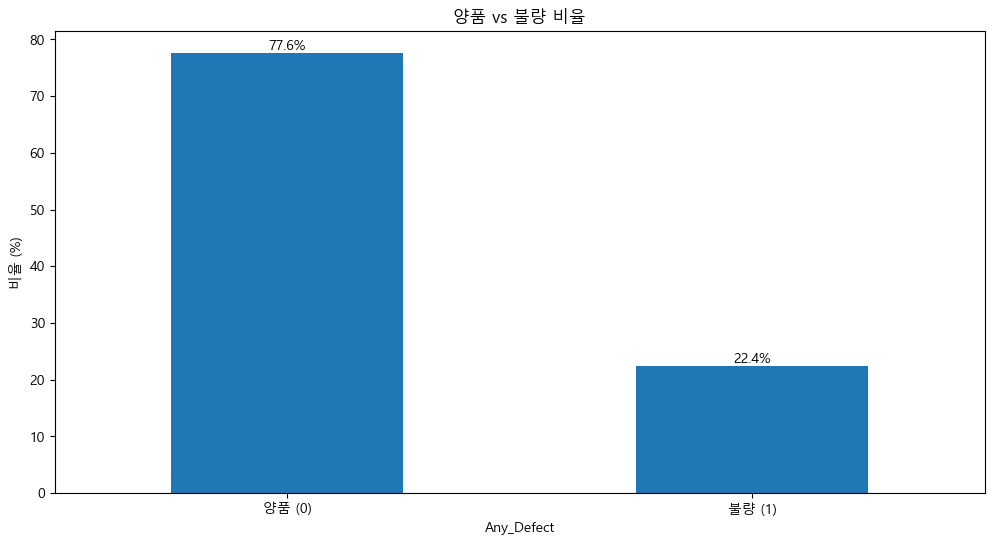

In [125]:
rates = df['Any_Defect'].value_counts(normalize=True).sort_index() * 100

plt.figure()
ax = rates.plot(kind='bar')
plt.xticks([0,1], ['양품 (0)', '불량 (1)'], rotation=0)
plt.ylabel('비율 (%)')
plt.title('양품 vs 불량 비율')

# 막대 위에 값 표시
for i, v in enumerate(rates):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center')
    
plt.show()

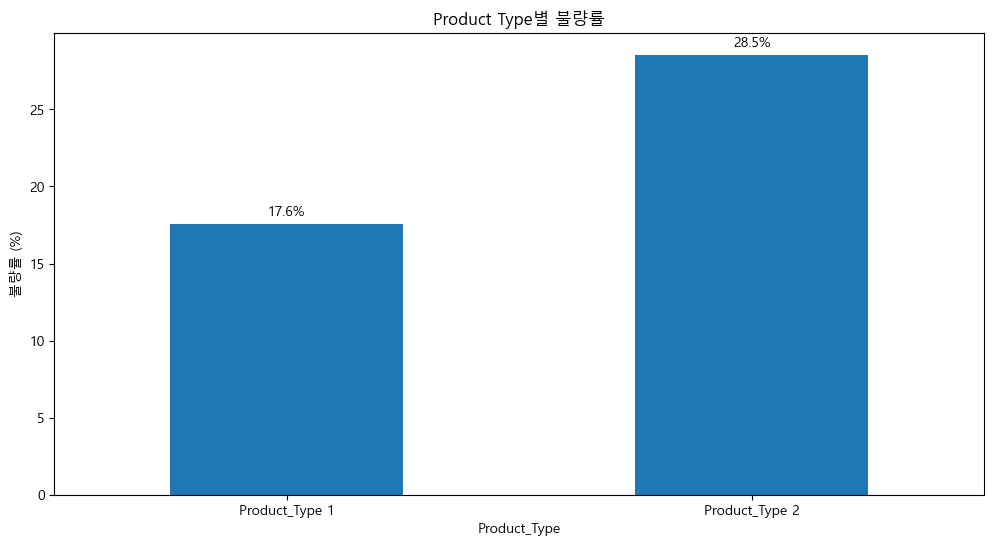

In [126]:
pt_defect = (
    df.groupby('Product_Type')['Any_Defect']
      .mean()
      .sort_index() * 100
)


plt.figure()
ax1 = pt_defect.plot(kind='bar')
plt.xticks(
    ticks=range(len(pt_defect)),
    labels=[f'Product_Type {int(i)}' for i in pt_defect.index],
    rotation=0
)

plt.ylabel('불량률 (%)')
plt.title('Product Type별 불량률')

# 막대 위에 값 표시
for i, v in enumerate(pt_defect):
    ax1.text(i, v + 0.5, f"{v:.1f}%", ha='center')
    
plt.show()

## 데이터 추출

### Product_Type에 따라 나눠서 저장

In [127]:
df1 = df[df['Product_Type'] == 1].copy()
df2 = df[df['Product_Type'] == 2].copy()

df1.to_csv("product_type_1.csv", index=False)
df2.to_csv("product_type_2.csv", index=False)

In [128]:
print("Product_Type 1:", df1.shape)
print("Product_Type 2:", df2.shape)
print("합계:", df1.shape[0] + df2.shape[0])

Product_Type 1: (4203, 61)
Product_Type 2: (3328, 61)
합계: 7531


In [129]:
# rename_map = {
#     "주조_shot_ID": "id"
#     "속도_1": "Velocity_1",
#     "속도_2": "Velocity_2",
#     "속도_3": "Velocity_3",
#     "최고속도": "High_Velocity",
#     "압력_실린더": "Cylinder_Pressure",
#     "압력_주조": "Casting_Pressure",
#     "최대압력_공기": "Air_Pressure_Max",
#     "최소압력_공기": "Air_Pressure_Min",
#     "압력_냉각수": "Coolant_Pressure",
#     "기존_시간_1": "Rapid_Rise_Time",
#     추가 작성
# }

# {
#     "공정_변수": {
#         "속도": {
#             "단계별_사출": ["Velocity_1", "Velocity_2", "Velocity_3"],
#             "최고_사출": "High_Velocity"
#         },
#         "압력": {
#             "실린더": "Cylinder_Pressure",
#             "주조": "Casting_Pressure",
#             "공기": ["Air_Pressure_Min", "Air_Pressure_Max"],
#             "냉각수": "Coolant_Pressure"
#         },
#         "시간": ["Rapid_Rise_Time", "Cycle_Time", "Pressure_Rise_Time", "Spray_Time"],
#         "물리량": ["Clamping_Force", "Factory_Humidity", "Factory_Temp", "Coolant_Temp"]
#     },
#     "불량_유형": {
#         "표면": ["Stain", "Dent", "Scratch", "Buring_Mark"],
#         "구조": ["Short_Shot", "Bubble", "Blow_Hole", "Deformation", "Crack"],
#         "이물질": ["Contamination", "Impurity", "Inclusions"]
#     }
# }



# df2 = df2.rename(columns=rename_map)

### 단일 건 행 기준 불량 분포 확인

In [130]:
mask_single = ~df_dropid.duplicated(keep=False)
df_single = df[mask_single]

In [131]:
print("="*60)
print("단일 건에서 양품/불량 분포")
print("="*60)

single_counts = df_single['Any_Defect'].value_counts()
print(single_counts)

print("\n비율(%)")
print(df_single['Any_Defect'].value_counts(normalize=True) * 100)

단일 건에서 양품/불량 분포
Any_Defect
0    1242
1     457
Name: count, dtype: int64

비율(%)
Any_Defect
0    73.101825
1    26.898175
Name: proportion, dtype: float64


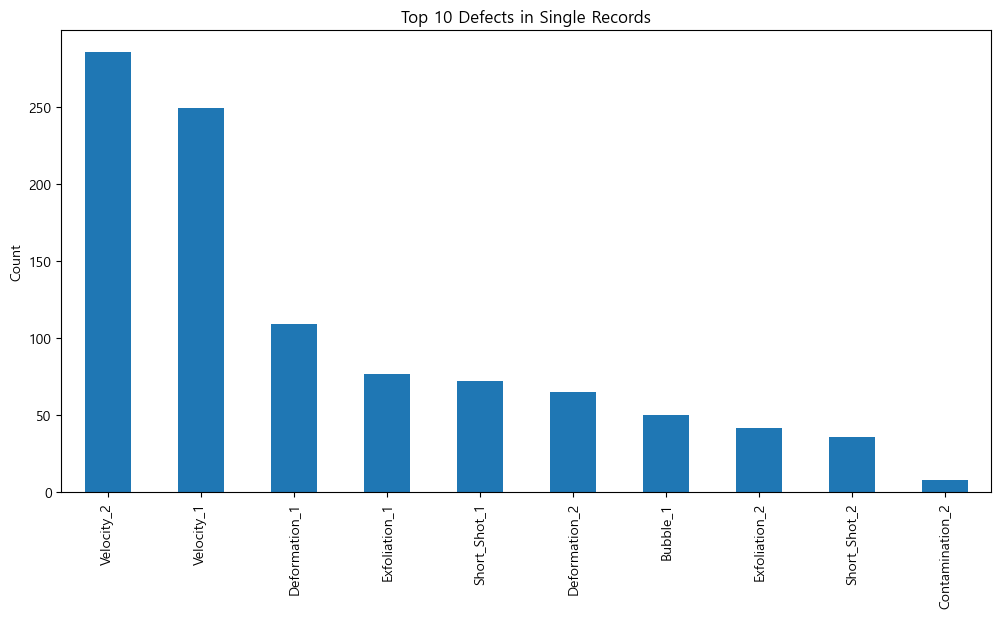

In [132]:
defect_cols = [c for c in df.columns if c.endswith('_1') or c.endswith('_2')]

single_defect_sum = df_single[defect_cols].sum().sort_values(ascending=False)

plt.figure()
single_defect_sum.head(10).plot(kind='bar')
plt.title('Top 10 Defects in Single Records')
plt.ylabel('Count')
plt.show()

In [133]:
df_dropid = df.drop(columns='Id')
mask_single = ~df_dropid.duplicated(keep=False)

df_single = df[mask_single]
df_duplicate = df[~mask_single]

print("단일 불량률:",
      df_single['Any_Defect'].mean()*100)

print("중복 불량률:",
      df_duplicate['Any_Defect'].mean()*100)

단일 불량률: 26.898175397292523
중복 불량률: 21.124828532235938


### 단일 컬럼 데이터 자세히 보기

In [134]:
df_single

,Id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Air_Pressure_Min,Air_Pressure_Max,Coolant_Temp,Coolant_Temp_Min,Coolant_Temp_Max,Coolant_Pressure,Factory_Temp,Factory_Temp_Min,Factory_Temp_Max,Factory_Humidity,Factory_Humidity_Min,Factory_Humidity_Max,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2,Vel_1_2_Diff,Vel_2_3_Diff,Vel_Total_Range,Any_Defect
0,1,1,1,0.144,0.170,0.188,2.134,214,0.008,10,258,20.7,0.044,1037,7.8,0.7,0.8,695.0,6.3,3,9,26.0,10,50,2.71,32.9,18.0,22.0,58.4,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.026,0.018,1.990,0
1,1002,1,2,0.144,0.170,0.182,2.124,217,0.008,11,257,20.7,0.044,1052,7.8,0.7,0.8,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.026,0.012,1.980,0
2,2003,1,3,0.144,0.170,0.182,2.116,214,0.008,11,257,20.8,0.041,1037,7.8,0.7,0.8,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.026,0.012,1.972,0
3,3004,1,4,0.144,0.170,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.026,0.012,1.993,1
4,4005,1,5,0.144,0.172,0.176,2.111,217,0.008,12,257,20.7,0.042,1052,7.8,0.7,0.8,697.9,6.4,3,9,26.1,10,50,2.69,32.9,18.0,22.0,57.8,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.028,0.004,1.967,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4802,4802619,2,619,0.152,0.166,0.208,2.674,265,0.011,19,370,34.0,0.040,595,10.1,2.0,2.7,669.0,6.9,3,9,27.6,10,50,2.71,35.3,18.0,22.0,56.2,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.014,0.042,2.522,0
4803,4803620,2,620,0.158,0.168,0.202,2.677,265,0.012,18,370,34.1,0.039,596,10.1,2.0,2.7,669.0,6.9,3,9,27.6,10,50,2.71,35.3,18.0,22.0,56.2,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.010,0.034,2.519,0
4804,4804621,2,621,0.158,0.166,0.202,2.709,265,0.012,18,370,34.1,0.040,596,10.1,2.0,2.7,669.5,6.9,3,9,27.6,10,50,2.70,35.3,18.0,22.0,56.4,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.008,0.036,2.551,0
4805,4805622,2,622,0.158,0.164,0.208,2.673,265,0.012,18,370,34.0,0.040,596,10.1,2.0,2.7,669.7,6.9,3,9,27.5,10,50,2.71,35.3,18.0,22.0,56.4,18.0,22.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.006,0.044,2.515,0


In [135]:
# 불량 컬럼 분리
defect_keywords = [
    'Short_Shot', 'Bubble', 'Exfoliation', 'Blow_Hole',
    'Stain', 'Dent', 'Deformation', 'Contamination',
    'Impurity', 'Crack', 'Scratch',
    'Buring_Mark', 'Inclusions'
]

defect_cols = [c for c in df.columns if any(k in c for k in defect_keywords)]

defect_cols_1 = [c for c in defect_cols if c.endswith('_1')]
defect_cols_2 = [c for c in defect_cols if c.endswith('_2')]

In [136]:
# 단일 건에서 불량 합계 계산
df_single['Defect_1_sum'] = df_single[defect_cols_1].sum(axis=1)
df_single['Defect_2_sum'] = df_single[defect_cols_2].sum(axis=1)

In [137]:
# 분류
df_single['Defect_Pattern'] = 'None'

df_single.loc[
    (df_single['Defect_1_sum'] > 0) & 
    (df_single['Defect_2_sum'] == 0),
    'Defect_Pattern'
] = 'Only_1'

df_single.loc[
    (df_single['Defect_1_sum'] == 0) & 
    (df_single['Defect_2_sum'] > 0),
    'Defect_Pattern'
] = 'Only_2'

df_single.loc[
    (df_single['Defect_1_sum'] > 0) & 
    (df_single['Defect_2_sum'] > 0),
    'Defect_Pattern'
] = 'Both'

In [138]:
# 개수 확인
df_single['Defect_Pattern'].value_counts()

Defect_Pattern
None      1242
Only_1     291
Only_2     128
Both        38
Name: count, dtype: int64

In [139]:
df_single[df_single['Defect_Pattern'] == 'Only_1'].head()

,Id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Air_Pressure_Min,Air_Pressure_Max,Coolant_Temp,Coolant_Temp_Min,Coolant_Temp_Max,Coolant_Pressure,Factory_Temp,Factory_Temp_Min,Factory_Temp_Max,Factory_Humidity,Factory_Humidity_Min,Factory_Humidity_Max,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2,Vel_1_2_Diff,Vel_2_3_Diff,Vel_Total_Range,Any_Defect,Defect_1_sum,Defect_2_sum,Defect_Pattern
3,3004,1,4,0.144,0.170,0.182,2.137,217,0.008,11,257,20.7,0.043,1051,7.8,0.7,0.8,696.4,6.3,3,9,26.1,10,50,2.69,32.9,18.0,22.0,58.2,18.0,22.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.026,0.012,1.993,1,1,0,Only_1
9,9011,1,11,0.144,0.168,0.184,2.145,217,0.008,11,257,20.7,0.042,1051,7.8,0.7,0.8,701.4,6.5,3,9,26.1,10,50,2.71,32.9,18.0,22.0,57.9,18.0,22.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.024,0.016,2.001,1,1,0,Only_1
28,28030,1,30,0.144,0.168,0.182,2.089,217,0.008,11,257,20.7,0.041,1052,7.9,0.7,0.8,711.9,6.8,3,9,26.1,10,50,2.70,32.8,18.0,22.0,58.5,18.0,22.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.024,0.014,1.945,1,1,0,Only_1
37,37039,1,39,0.144,0.166,0.176,2.155,217,0.008,11,255,20.7,0.041,1052,7.9,0.7,0.8,716.7,7.0,3,9,26.1,10,50,2.69,32.8,18.0,22.0,58.3,18.0,22.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.022,0.010,2.011,1,1,0,Only_1
40,40042,1,42,0.146,0.168,0.186,2.121,214,0.008,11,257,20.7,0.044,1037,7.9,0.7,0.8,718.0,6.9,3,9,26.1,10,50,2.70,32.9,18.0,22.0,58.3,18.0,22.0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.022,0.018,1.975,1,1,0,Only_1


In [140]:
df_single[df_single['Defect_Pattern'] == 'Both'].head()

,Id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Air_Pressure_Min,Air_Pressure_Max,Coolant_Temp,Coolant_Temp_Min,Coolant_Temp_Max,Coolant_Pressure,Factory_Temp,Factory_Temp_Min,Factory_Temp_Max,Factory_Humidity,Factory_Humidity_Min,Factory_Humidity_Max,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2,Vel_1_2_Diff,Vel_2_3_Diff,Vel_Total_Range,Any_Defect,Defect_1_sum,Defect_2_sum,Defect_Pattern
22,22024,1,24,0.142,0.166,0.180,2.155,218,0.007,11,257,20.7,0.041,1053,7.8,0.7,0.8,708.4,6.6,3,9,26.1,10,50,2.72,32.8,18.0,22.0,58.2,18.0,22.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.024,0.014,2.013,1,1,1,Both
41,41043,1,43,0.146,0.168,0.186,2.121,214,0.008,11,257,20.7,0.044,1037,7.9,0.7,0.8,719.0,6.8,3,9,26.1,10,50,2.71,32.9,18.0,22.0,58.2,18.0,22.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0.022,0.018,1.975,1,1,1,Both
42,42044,1,44,0.144,0.166,0.186,2.120,214,0.007,11,255,20.8,0.044,1037,7.8,0.7,0.8,719.0,6.8,3,9,26.1,10,50,2.71,32.9,18.0,22.0,58.2,18.0,22.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0.022,0.020,1.976,1,1,1,Both
109,109111,1,111,0.144,0.168,0.176,2.164,217,0.008,11,254,20.6,0.041,1052,7.8,0.7,0.8,685.3,5.4,3,9,26.1,10,50,2.69,33.4,18.0,22.0,55.5,18.0,22.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0.024,0.008,2.020,1,1,1,Both
114,114121,1,121,0.144,0.166,0.184,2.131,214,0.008,12,259,20.7,0.044,1038,7.9,0.7,0.8,672.4,6.6,3,9,26.3,10,50,2.68,34.1,18.0,22.0,54.6,18.0,22.0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.022,0.018,1.987,1,1,1,Both


### 중복 데이터 처리

In [141]:
# 불량 컬럼명 먼저 구분
# defect_cols = [c for c in df.columns 
#                if any(x in c for x in [
#                    'Short_Shot', 'Bubble', 'Exfoliation', 'Blow_Hole',
#                    'Stain', 'Dent', 'Deformation', 'Contamination',
#                    'Impurity', 'Crack', 'Scratch',
#                    'Buring_Mark', 'Inclusions'
#                ])]

# Any_Defect
# df['Any_Defect'] = (df[defect_cols].sum(axis=1) > 0).astype(int)


df_dedup = df.drop_duplicates(subset=df.columns.drop('Id'))

print("원본 row:", df.shape[0], "건")
print("중복 제거 후 row:", df_dedup.shape[0], "건")

print("원본 불량률:", df['Any_Defect'].mean().round(4))
print("제거 후 불량률:", df_dedup['Any_Defect'].mean().round(4))

원본 row: 7531 건
중복 제거 후 row: 4615 건
원본 불량률: 0.2243
제거 후 불량률: 0.2325


In [142]:
# ① 불량 관련 컬럼 자동 수집
# 컬럼명이 불량 유형으로 시작하는 것들만 골라냄
defect_cols_all = [c for c in df_dedup.columns if any(c.startswith(d) for d in [
    'Short_Shot','Bubble','Exfoliation','Blow_Hole','Stain','Dent',
    'Deformation','Contamination','Impurity','Crack','Scratch','Buring_Mark','Inclusions'
])]

# ② 불량 여부 (0/1) 생성
# 불량 컬럼 중 하나라도 1이면 불량(1), 전부 0이면 양품(0)
df_dedup['Defect_Status'] = (df_dedup[defect_cols_all].sum(axis=1) > 0).astype(int)

# ③ 불량 유형별 컬럼 매핑
# 어떤 컬럼이 어떤 불량 유형인지 딕셔너리로 정의
defect_types = {
    'Short_Shot':  ['Short_Shot_1','Short_Shot_2'],
    'Blow_Hole':   ['Blow_Hole_1','Blow_Hole_2'],
    'Exfoliation': ['Exfoliation_1','Exfoliation_2'],
    'Stain':       ['Stain_1','Stain_2'],
    'Deformation': ['Deformation_1','Deformation_2'],
    'Bubble':      ['Bubble_1','Bubble_2'],
    'Other': ['Dent_1','Dent_2','Contamination_1','Contamination_2',
              'Impurity_1','Impurity_2','Crack_1','Crack_2',
              'Scratch_1','Scratch_2','Buring_Mark_1','Buring_Mark_2',
              'Inclusions_1','Inclusions_2']
}

# ④ 행마다 불량 유형 라벨을 반환하는 함수
def get_defect_label(row):
    # 양품이면 바로 Normal 반환
    if row['Defect_Status'] == 0: return 'Normal'
    
    # 불량이면 어떤 유형인지 순서대로 확인
    for label, cols in defect_types.items():
        # 실제 데이터에 존재하는 컬럼만 필터링 (없는 컬럼 오류 방지)
        valid = [c for c in cols if c in row.index]
        # 해당 유형 컬럼 중 하나라도 1이면 그 유형 반환
        if row[valid].sum() > 0: return label
    
    # 불량인데 어떤 유형에도 안 걸리면 Other
    return 'Other'

# ⑤ 전체 행에 함수 적용해서 Defect_Type 컬럼 생성
df_dedup['Defect_Type'] = df_dedup.apply(get_defect_label, axis=1)


# 타겟 변수
defect_cols_all = [c for c in df_dedup.columns if any(c.startswith(d) for d in [
    'Short_Shot','Bubble','Exfoliation','Blow_Hole','Stain','Dent',
    'Deformation','Contamination','Impurity','Crack','Scratch','Buring_Mark','Inclusions'
])]
df_dedup['Defect_Status'] = (df_dedup[defect_cols_all].sum(axis=1) > 0).astype(int)


print("✅ 타겟 변수 생성 완료")
print(f"\n[Defect_Status 분포]")
print(df_dedup['Defect_Status'].value_counts().to_string())
print(f"\n불량률: {df_dedup['Defect_Status'].mean()*100:.1f}%")
print(f"\n[Defect_Type 분포]")
print(df_dedup['Defect_Type'].value_counts().to_string())

✅ 타겟 변수 생성 완료

[Defect_Status 분포]
Defect_Status
0    3542
1    1073

불량률: 23.3%

[Defect_Type 분포]
Defect_Type
Normal         3542
Short_Shot      387
Exfoliation     196
Blow_Hole       169
Deformation     152
Stain            72
Bubble           59
Other            38
